# Chapter 9 — Chronopotentiometry

This notebook adapts Chapter 9, *Chronopotentiometry*, of Michael Honeychurch's
*Simulating Electrochemical Reactions in Mathematica* (SERM) into Python. The
source chapter and its companion `ExplicitChronoPot` notebooks develop the
analytic theory of constant-current chronopotentiometry by Laplace transform,
derive the **Sand equation** for the transition time, and then simulate the
potential–time transient with an explicit finite-difference scheme whose surface
boundary conditions are fixed by the *flux* (the controlled current) rather than
by the *potential*.

We re-derive the theory, re-implement the explicit FD solver idiomatically in
vectorised numpy, regenerate every figure in matplotlib, and validate the
simulation against the closed-form Sand equation provided independently by
`serm.echem.sand_transition_time`.

## What this chapter delivers

* The non-dimensional governing equation and the **current-controlled** surface
  boundary conditions (3-point flux approximation).
* An explicit FD simulator returning surface concentrations and the
  potential–time transient (potential obtained by rooting the Butler–Volmer
  relation at each step).
* The reversible chronopotentiometric **wave shape**
  $E = E^{\circ\prime} + \tfrac{RT}{nF}\ln\frac{\tau^{1/2}-t^{1/2}}{t^{1/2}}$,
  with the quarter-wave potential at $t=\tau/4$.
* A **current-reversal** simulation that recovers the analytic reversal
  transition $\tau_2=\tau_1/3$.
* **Validation:** $i\sqrt{\tau}$ is constant and matches the Sand equation, the
  simulated transient follows the analytic wave shape, and the reversal
  transition obeys $\tau_2=\tau_1/3$. (The two-component / EE successive-transfer
  simulator, with $\tau_2=3\tau_1$, is developed in
  `extras/09_chronopot_reversal_and_EE.ipynb`.)


## 1. Governing equation and the Sand equation

For a planar electrode with semi-infinite linear diffusion, the oxidised species
O obeys Fick's second law

$$\frac{\partial c_O}{\partial t} = D\,\frac{\partial^2 c_O}{\partial x^2},$$

with $c_O(x,0)=c^*$, $c_O(\infty,t)=c^*$, and R absent initially. In a
**galvanostatic** (constant-current) experiment the surface flux is fixed by the
applied current $i$:

$$\frac{i}{nFA} = D\left.\frac{\partial c_O}{\partial x}\right|_{x=0}=\text{const}.$$

Honeychurch solves this by Laplace transform (Chapter 9, following the steps of
Section 5.2). The surface concentration of O falls linearly in $\sqrt{t}$:

$$c_O(0,t) = c^* - \frac{2 i}{nFA}\sqrt{\frac{t}{\pi D}}.$$

The **transition time** $\tau$ is the instant the surface concentration reaches
zero — diffusion can no longer supply reactant fast enough to sustain the
imposed current, and the potential swings sharply to the next available process.
Setting $c_O(0,\tau)=0$ gives the **Sand equation**:

$$\boxed{\,i\,\tau^{1/2} = \frac{1}{2}\,nFA\,c^*\sqrt{\pi D}\,}
\qquad\Longleftrightarrow\qquad
\tau = \frac{\pi D\,(nFAc^*)^2}{4 i^2}.$$

The product $i\,\tau^{1/2}$ is a constant of the system — independent of the
applied current — and is independent of the electrode kinetics. This is exactly
the closed form returned by `serm.echem.sand_transition_time`, which we use as
the independent reference in the validation section.


## 2. The reversible wave shape and the quarter-wave potential

For a reversible couple the surface concentrations of O and R are tied to the
potential by the Nernst equation. With R produced only by the electrode reaction,
the surface concentration of R grows as the surface concentration of O is
depleted, and substituting the Laplace-transform results into the Nernst
equation gives the chronopotentiometric **wave shape** (Honeychurch eq. for
$E$ vs $t$):

$$E(t) = E^{\circ\prime} + \frac{RT}{2nF}\ln\frac{D_R}{D_O}
        + \frac{RT}{nF}\ln\frac{\tau^{1/2}-t^{1/2}}{t^{1/2}},
        \qquad 0 < t < \tau.$$

For equal diffusion coefficients ($D_O=D_R$) the middle term vanishes. At
$t=\tau/4$ the logarithm is $\ln\frac{\tau^{1/2}-\tau^{1/2}/2}{\tau^{1/2}/2}
=\ln 1 = 0$, so $E=E^{\circ\prime}$ (for equal $D$). This defines the
**quarter-wave potential** $E_{\tau/4}$, the chronopotentiometric analogue of
the polarographic half-wave potential. As $t\to\tau$ the argument $\to 0$ and
$E\to-\infty$: the sharp potential transition.

We work in the dimensionless potential $\mathcal{E}=\frac{nF}{RT}(E-E_{\tau/4})$,
for which the reversible wave is simply

$$\mathcal{E}(t) = \ln\frac{\tau^{1/2}-t^{1/2}}{t^{1/2}}.$$


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import serm
from serm.echem import sand_transition_time, F, R

np.set_printoptions(precision=5, suppress=True)


In [2]:
def reversible_wave(t, tau):
    """Dimensionless reversible chronopotentiometric wave E(t).

    Returns the dimensionless potential ``E = (nF/RT)(E - E_tau/4)`` for a
    reversible couple with equal diffusion coefficients, valid for 0 < t < tau:

        E(t) = ln( (sqrt(tau) - sqrt(t)) / sqrt(t) ).

    Parameters
    ----------
    t : array_like
        Time(s), same units as ``tau`` (only the ratio t/tau matters).
    tau : float
        Transition time.

    Returns
    -------
    numpy.ndarray
        Dimensionless potential; -inf at t = tau, +inf at t = 0.
    """
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.log((np.sqrt(tau) - np.sqrt(t)) / np.sqrt(t))


Plot the analytic wave. The transition at $t=\tau$ is the diverging tail; the
curve crosses zero (the quarter-wave potential) at exactly $t=\tau/4$.

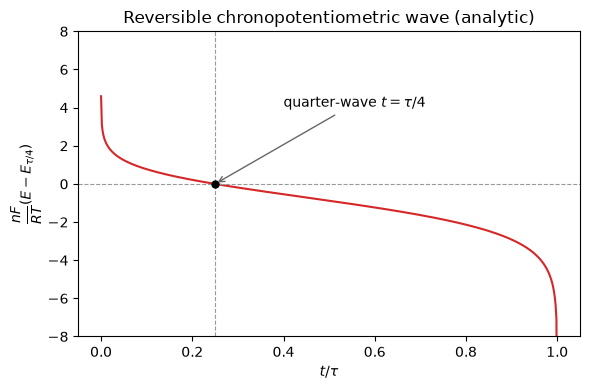

In [3]:
tau = 1.0
t = np.linspace(1e-4, tau - 1e-6, 600)
E = reversible_wave(t, tau)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t / tau, E, color="tab:red", lw=1.5)
ax.axvline(0.25, color="0.6", ls="--", lw=0.8)
ax.axhline(0.0, color="0.6", ls="--", lw=0.8)
ax.plot(0.25, 0.0, "ko", ms=5)
ax.annotate(r"quarter-wave $t=\tau/4$", (0.25, 0.0),
            xytext=(0.4, 4), arrowprops=dict(arrowstyle="->", color="0.4"))
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"$\dfrac{nF}{RT}(E-E_{\tau/4})$")
ax.set_ylim(-8, 8)
ax.set_title("Reversible chronopotentiometric wave (analytic)")
fig.tight_layout()
plt.show()


## 3. Explicit finite-difference simulation

Following Honeychurch's `ExplicitChronoPot` notebooks, we non-dimensionalise
distance and time so the explicit update of the interior nodes is a single
diffusion stencil. Let $D_M = D\,\Delta t/\Delta x^2$ be the dimensionless
diffusion (model) coefficient and let there be $n$ time steps. The interior
update for either species $c_j$ is

$$c_j^{k+1} = D_M\,c_{j-1}^{k} + (1-2D_M)\,c_j^{k} + D_M\,c_{j+1}^{k},$$

a three-point correlation with kernel $[D_M,\,1-2D_M,\,D_M]$ (stable for
$D_M\le \tfrac12$; Honeychurch uses $D_M=0.35$).

**Current-controlled surface boundary.** The dimensionless current is related to
the surface flux by a 3-point (second-order) one-sided derivative,

$$i_\text{dim} = \frac{2i}{\sqrt{D_M(n-1)}},\qquad
i_\text{dim} = -3c_{O,1} + 4c_{O,2} - c_{O,3}
\;\;(\text{flux of O}),$$

so that, after one diffusion step has produced the interior values
$c_{O,2},c_{O,3}$ (and $c_{R,2},c_{R,3}$), the surface values are recovered from

$$c_{O,1} = \tfrac13\big(i_\text{dim} + 4c_{O,2} - c_{O,3}\big),\qquad
c_{R,1} = \tfrac13\big(\!-i_\text{dim} + 4c_{R,2} - c_{R,3}\big).$$

(O is consumed and R produced in equal and opposite flux, hence the sign flip.)
This is the galvanostatic analogue of the *concentration*-controlled surface
condition used for voltammetry in earlier chapters: here the **flux**, not the
surface concentration, is imposed.

The simulation runs until the surface concentration of O would go negative —
that is the discrete transition time. Honeychurch stops with `NestWhileList`;
we stop the loop on the same condition.


In [4]:
def simulate_chronopot(i_dimensionless=-0.9, n=401, DM=0.35):
    """Explicit FD simulation of a constant-current chronopotentiogram.

    Port of Honeychurch's ``explicitChronoPot2``: an explicit diffusion update
    with current-controlled (flux) surface boundary conditions, run until the
    surface concentration of O reaches zero (the discrete transition time).

    Concentrations are dimensionless (bulk = 1). Only the two surface
    concentrations (O, R) are returned per step, which is all the potential
    calculation needs.

    Parameters
    ----------
    i_dimensionless : float
        Dimensionless applied current ``i`` (negative = reduction of O).
    n : int
        Number of time increments in the full grid (sets dt via tau=1).
    DM : float
        Dimensionless diffusion coefficient D*dt/dx^2 (<= 0.5 for stability).

    Returns
    -------
    cO_surf, cR_surf : numpy.ndarray
        Surface concentrations of O and R at each completed time step
        (length = number of steps before the transition time).
    n_steps : int
        Number of steps taken (the discrete transition index).
    """
    # number of spatial nodes: enough that the diffusion layer never reaches
    # the outer (bulk) boundary -- Honeychurch's m = 1 + ceil(6 sqrt(DM (n-1))).
    m = 1 + int(np.ceil(6.0 * np.sqrt(DM * (n - 1))))
    iDim = (2.0 * i_dimensionless) / np.sqrt(DM * (n - 1))

    cO = np.ones(m)            # O: bulk concentration 1 everywhere
    cR = np.zeros(m)           # R: absent initially
    kernel = np.array([DM, 1.0 - 2.0 * DM, DM])

    cO_surf, cR_surf = [], []
    for _ in range(n - 1):
        # diffuse interior nodes (correlate keeps interior; ends reset below)
        newO = cO.copy()
        newR = cR.copy()
        newO[1:-1] = DM * cO[:-2] + (1.0 - 2.0 * DM) * cO[1:-1] + DM * cO[2:]
        newR[1:-1] = DM * cR[:-2] + (1.0 - 2.0 * DM) * cR[1:-1] + DM * cR[2:]
        # current-controlled surface node (3-point flux)
        newO[0] = (iDim + 4.0 * newO[1] - newO[2]) / 3.0
        newR[0] = (-iDim + 4.0 * newR[1] - newR[2]) / 3.0
        # outer boundary clamped to bulk
        newO[-1], newR[-1] = 1.0, 0.0
        cO, cR = newO, newR
        if cO[0] < 0.0:        # surface O depleted -> transition time reached
            break
        cO_surf.append(cO[0])
        cR_surf.append(cR[0])
    return np.array(cO_surf), np.array(cR_surf), len(cO_surf)


### Potential from the surface concentrations

At each step the dimensionless potential $\mathcal{E}=\frac{nF}{RT}(E-E^{\circ\prime})$
is obtained from the dimensionless Butler–Volmer equation (Honeychurch eq. 9.7),

$$\frac{i}{k_{s,\text{dim}}}
   = c_R(0)\,e^{(1-\alpha)\mathcal{E}} - c_O(0)\,e^{-\alpha\mathcal{E}},$$

rooted for $\mathcal{E}$ at each step. With a very large rate constant
($k_s\to\infty$) the left side $\to 0$ and the equation collapses to the Nernst
form $c_R e^{(1-\alpha)\mathcal{E}} = c_O e^{-\alpha\mathcal{E}}$, i.e.
$\mathcal{E}=\ln(c_O/c_R)$ — the reversible limit. We root the full
Butler–Volmer expression with `scipy.optimize.brentq` (replacing Mathematica's
`FindRoot`).


In [5]:
def potentials_from_surface(cO_surf, cR_surf, i_dimensionless=-0.9,
                            ks=1.0e6, alpha=0.5, n=401, DM=0.35,
                            D=1.0e-5):
    """Dimensionless potential at each step by rooting Butler-Volmer.

    Solves  i/ksDim = cR e^{(1-a)E} - cO e^{-a E}  for E at each time step,
    where ksDim = ks * sqrt(1/(D*DM*(n-1))) is the dimensionless rate constant
    (Honeychurch). brentq replaces Mathematica's FindRoot.
    """
    ksDim = ks * np.sqrt(1.0 / (D * DM * (n - 1)))
    rhs = i_dimensionless / ksDim

    def bv(E, cO, cR):
        return cR * np.exp((1.0 - alpha) * E) - cO * np.exp(-alpha * E) - rhs

    pots = np.empty(len(cO_surf))
    for k, (cO, cR) in enumerate(zip(cO_surf, cR_surf)):
        # bracket widely; reduction drives E negative as O is consumed
        pots[k] = brentq(bv, -60.0, 60.0, args=(cO, cR), xtol=1e-10)
    return pots


In [6]:
i_dim = -0.9
n = 401
cO_s, cR_s, n_steps = simulate_chronopot(i_dim, n=n)
pots = potentials_from_surface(cO_s, cR_s, i_dim, n=n)
print(f"transition reached after {n_steps} of {n - 1} steps")
print(f"discrete tau (tau/t_total) = {n_steps / (n - 1):.4f}")
print(f"i * sqrt(tau_discrete)     = {abs(i_dim) * np.sqrt(n_steps / (n - 1)):.4f}")
print(f"sqrt(pi)/2 (Sand target)   = {np.sqrt(np.pi) / 2:.4f}")


transition reached after 387 of 400 steps
discrete tau (tau/t_total) = 0.9675
i * sqrt(tau_discrete)     = 0.8853
sqrt(pi)/2 (Sand target)   = 0.8862


The simulated transient. The discrete transition time is the step at which the
surface O concentration first goes negative; we stop there, giving the clean
sigmoidal transient (Honeychurch's `explicitChronoPot2`, which avoids the
spurious negative-concentration tail produced by running past $\tau$).

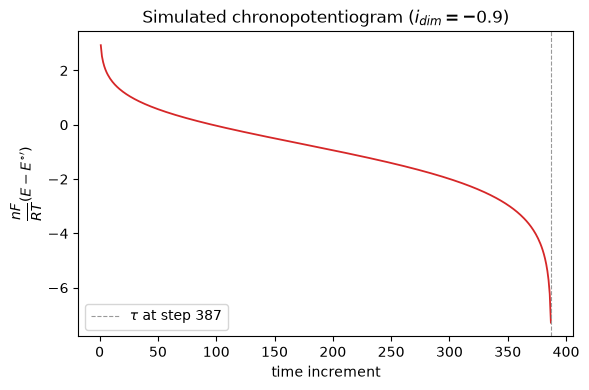

In [7]:
tsteps = np.arange(1, n_steps + 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tsteps, pots, color="tab:red", lw=1.3)
ax.axvline(n_steps, color="0.6", ls="--", lw=0.8,
           label=fr"$\tau$ at step {n_steps}")
ax.set_xlabel("time increment")
ax.set_ylabel(r"$\dfrac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_title(f"Simulated chronopotentiogram ($i_{{dim}}={i_dim}$)")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Validation

**Strategy (Spec §5, option 1 — independent closed-form check).** Two
independent cross-checks against analytic theory computed outside the FD code:

1. **Sand equation.** The Sand equation predicts $i\sqrt{\tau}=\text{const}$,
   independent of the applied current. In the dimensionless simulation
   (transition time normalised so the *full* grid spans $t/\tau$), the discrete
   product $|i|\sqrt{\tau_\text{discrete}}$ must equal $\sqrt{\pi}/2\approx0.8862$,
   which is exactly $i\sqrt{\tau}$ from the Sand equation written in dimensionless
   form. We confirm this product is constant across **different applied
   currents** and matches the target, and we separately confirm the *dimensional*
   Sand equation from `serm.echem.sand_transition_time` reproduces the same
   constant.

2. **Wave shape.** The simulated transient (large $k_s$ → reversible) must follow
   the analytic reversible wave
   $\mathcal{E}(t)=\ln\frac{\tau^{1/2}-t^{1/2}}{t^{1/2}}$ over the interior of
   the transient (excluding the singular edges $t\to0,\tau$, as the source does).


In [8]:
# --- Check 1: Sand product constant across currents and matches sqrt(pi)/2 ---
target = np.sqrt(np.pi) / 2.0
# The transition fits in the grid only when |i| > sqrt(pi)/2 (otherwise the
# diffusion layer never depletes within the n-1 steps), so we sweep currents
# above that threshold.
products = {}
for ic in (-0.9, -1.1, -1.3, -1.5):
    _cO, _cR, ns = simulate_chronopot(ic, n=n)
    products[ic] = abs(ic) * np.sqrt(ns / (n - 1))
for ic, p in products.items():
    print(f"i_dim = {ic:+.2f}   i*sqrt(tau) = {p:.4f}   rel.err = "
          f"{abs(p - target) / target:.3%}")

max_rel = max(abs(p - target) / target for p in products.values())
assert max_rel < 0.03, f"Sand product off by {max_rel:.3%}"
print(f"\nPASS: i*sqrt(tau) constant = {target:.4f} (sqrt(pi)/2) "
      f"across currents, max rel.err {max_rel:.3%}")


i_dim = -0.90   i*sqrt(tau) = 0.8853   rel.err = 0.110%
i_dim = -1.10   i*sqrt(tau) = 0.8851   rel.err = 0.123%
i_dim = -1.30   i*sqrt(tau) = 0.8841   rel.err = 0.240%
i_dim = -1.50   i*sqrt(tau) = 0.8842   rel.err = 0.225%

PASS: i*sqrt(tau) constant = 0.8862 (sqrt(pi)/2) across currents, max rel.err 0.240%


In [9]:
# --- Cross-check the dimensional Sand equation from serm.echem ---
# Pick physical numbers; the dimensionless constant i*sqrt(tau)/(nFAc sqrt(D))
# must equal sqrt(pi)/2 exactly for the closed form.
n_e, A, D, c_bulk, i_app = 1, 0.01, 1.0e-5, 1.0e-6, 1.0e-5  # cm,cm^2/s,mol/cm^3,A
tau_sand = sand_transition_time(n_e, A, D, c_bulk, i_app)
const = i_app * np.sqrt(tau_sand) / (n_e * F * A * c_bulk * np.sqrt(D))
print(f"tau (Sand)                              = {tau_sand:.4f} s")
print(f"i*sqrt(tau)/(nFAc sqrt(D))              = {const:.6f}")
print(f"sqrt(pi)/2                              = {target:.6f}")
assert abs(const - target) < 1e-9
print("PASS: serm.echem Sand equation reproduces sqrt(pi)/2")


tau (Sand)                              = 0.0731 s
i*sqrt(tau)/(nFAc sqrt(D))              = 0.886227
sqrt(pi)/2                              = 0.886227
PASS: serm.echem Sand equation reproduces sqrt(pi)/2


In [10]:
# --- Check 2: simulated transient follows the analytic reversible wave ---
# dimensionless time of each step, normalised so transition time = 1
t_norm = tsteps / n_steps           # in (0, 1]; tau corresponds to 1
analytic = reversible_wave(t_norm, 1.0)

# compare over the interior, excluding singular edges (t->0 and t->tau)
mask = (t_norm > 0.05) & (t_norm < 0.95)
rmse = np.sqrt(np.mean((pots[mask] - analytic[mask]) ** 2))
print(f"RMSE(simulated, analytic wave) over 0.05<t/tau<0.95 = {rmse:.4f}")
assert rmse < 0.15, f"wave-shape RMSE too large: {rmse:.4f}"
print(f"PASS: simulated transient matches the analytic reversible wave "
      f"(RMSE {rmse:.4f})")


RMSE(simulated, analytic wave) over 0.05<t/tau<0.95 = 0.0056
PASS: simulated transient matches the analytic reversible wave (RMSE 0.0056)


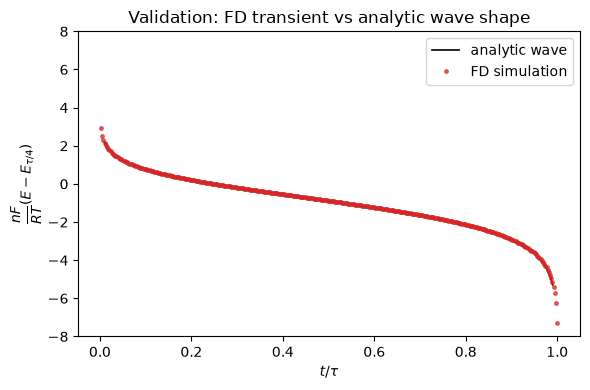

In [11]:
# overlay simulated vs analytic wave
fig, ax = plt.subplots(figsize=(6, 4))
tt = np.linspace(0.01, 0.99, 400)
ax.plot(tt, reversible_wave(tt, 1.0), color="k", lw=1.2, label="analytic wave")
ax.plot(t_norm, pots, "o", ms=2.5, color="tab:red", alpha=0.7,
        label="FD simulation")
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"$\dfrac{nF}{RT}(E-E_{\tau/4})$")
ax.set_ylim(-8, 8)
ax.set_title("Validation: FD transient vs analytic wave shape")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Current-reversal chronopotentiometry

In a **current-reversal** experiment the galvanostatic current is held at $+i$
until the first transition time $\tau_1$ (here we reverse exactly *at* $\tau_1$),
then switched to $-i$. During the reversal segment the product R, accumulated
near the electrode during the forward step, is re-oxidised back to O. A
**second transition** occurs when the surface concentration of R is exhausted.

**Analytic prediction.** For reversal at $t_1=\tau_1$, the Laplace-transform
solution gives a surface concentration of R proportional to

$$t^{1/2} - 2\,(t-\tau_1)^{1/2},\qquad t>\tau_1 .$$

Setting this to zero at $t=\tau_1+\tau_2$,

$$\sqrt{\tau_1+\tau_2} = 2\sqrt{\tau_2}
  \;\Longrightarrow\; \tau_1+\tau_2 = 4\tau_2
  \;\Longrightarrow\; \boxed{\;\tau_2 = \tfrac13\,\tau_1\;}.$$

The reversal transition is reached after only one third of the forward
transition time — a classic diagnostic for a stable, freely-diffusing product
(no following chemistry). We simulate this with the same explicit FD engine: run
the forward step to $\tau_1$, flip the sign of the dimensionless current, and
continue the *full* concentration field until the surface R is depleted.

In [12]:
def simulate_reversal(i_dimensionless=-0.9, n=401, DM=0.35):
    """Explicit FD current-reversal chronopotentiogram.

    Runs the forward galvanostatic step until the surface O is depleted
    (first transition time tau_1), then reverses the current sign and continues
    the *same* concentration field until the surface R is depleted (second
    transition time tau_2). Port of Honeychurch's reversal experiment
    (``stopBack`` / sign flip of ``iDim``) using the full field rather than a
    NestWhileList.

    Parameters
    ----------
    i_dimensionless : float
        Dimensionless forward current (negative = reduction of O).
    n : int
        Number of time increments in the forward grid (sets dt via tau=1).
    DM : float
        Dimensionless diffusion coefficient (<= 0.5 for stability).

    Returns
    -------
    cO_fwd, cR_fwd : numpy.ndarray
        Surface concentrations during the forward segment.
    cO_rev, cR_rev : numpy.ndarray
        Surface concentrations during the reversal segment.
    n1, n2 : int
        Step counts of the forward and reversal segments (discrete tau_1, tau_2).
    """
    m = 1 + int(np.ceil(6.0 * np.sqrt(DM * (n - 1))))
    iDim = (2.0 * i_dimensionless) / np.sqrt(DM * (n - 1))

    cO = np.ones(m)
    cR = np.zeros(m)

    def step(cO, cR, iDim):
        newO = cO.copy()
        newR = cR.copy()
        newO[1:-1] = DM * cO[:-2] + (1.0 - 2.0 * DM) * cO[1:-1] + DM * cO[2:]
        newR[1:-1] = DM * cR[:-2] + (1.0 - 2.0 * DM) * cR[1:-1] + DM * cR[2:]
        newO[0] = (iDim + 4.0 * newO[1] - newO[2]) / 3.0
        newR[0] = (-iDim + 4.0 * newR[1] - newR[2]) / 3.0
        newO[-1], newR[-1] = 1.0, 0.0
        return newO, newR

    # --- forward segment: stop when surface O depletes (tau_1) ---
    cO_fwd, cR_fwd = [], []
    for _ in range(n - 1):
        cO, cR = step(cO, cR, iDim)
        if cO[0] < 0.0:
            break
        cO_fwd.append(cO[0])
        cR_fwd.append(cR[0])

    # --- reversal segment: flip current, stop when surface R depletes (tau_2) ---
    iDim = -iDim
    cO_rev, cR_rev = [], []
    for _ in range(4 * (n - 1)):
        cO, cR = step(cO, cR, iDim)
        if cR[0] < 0.0:
            break
        cO_rev.append(cO[0])
        cR_rev.append(cR[0])

    return (np.array(cO_fwd), np.array(cR_fwd),
            np.array(cO_rev), np.array(cR_rev),
            len(cO_fwd), len(cO_rev))


Run the reversal simulation and convert both segments to potential by rooting
the same dimensionless Butler–Volmer relation used in §3. The forward segment
drives the potential down (O being reduced); after reversal the potential
climbs as R is re-oxidised, until the second transition sends it sharply back.

In [13]:
i_dim = -0.9
n = 401
cO_f, cR_f, cO_r, cR_r, n1, n2 = simulate_reversal(i_dim, n=n)

pots_f = potentials_from_surface(cO_f, cR_f, i_dim, n=n)
# during reversal the applied current is +|i|; the BV rhs uses the *signed*
# current, so pass the reversed sign for the reversal segment.
pots_r = potentials_from_surface(cO_r, cR_r, -i_dim, n=n)

pots_all = np.concatenate([pots_f, pots_r])
steps_all = np.arange(1, n1 + n2 + 1)

print(f"forward transition  tau_1 = {n1} steps")
print(f"reversal transition tau_2 = {n2} steps")
print(f"ratio tau_2 / tau_1       = {n2 / n1:.4f}   (analytic 1/3 = {1/3:.4f})")


forward transition  tau_1 = 387 steps
reversal transition tau_2 = 129 steps
ratio tau_2 / tau_1       = 0.3333   (analytic 1/3 = 0.3333)


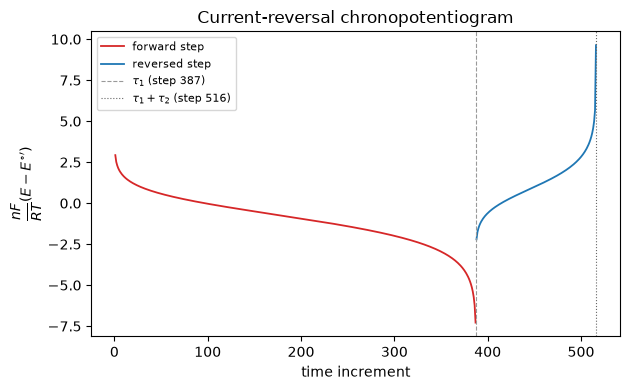

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(steps_all[:n1], pots_f, color="tab:red", lw=1.3, label="forward step")
ax.plot(steps_all[n1:], pots_r, color="tab:blue", lw=1.3, label="reversed step")
ax.axvline(n1, color="0.6", ls="--", lw=0.8, label=fr"$\tau_1$ (step {n1})")
ax.axvline(n1 + n2, color="0.4", ls=":", lw=0.8, label=fr"$\tau_1+\tau_2$ (step {n1 + n2})")
ax.set_xlabel("time increment")
ax.set_ylabel(r"$\dfrac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_title("Current-reversal chronopotentiogram")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### Validation — reversal transition $\tau_2=\tau_1/3$

**Strategy (Spec §1, tier 1 — independent closed-form check).** The reversal
transition-time ratio $\tau_2/\tau_1=1/3$ is an exact analytic result derived
above from the Laplace-transform surface concentration of R, independent of the
FD code. We assert the discrete ratio recovers $1/3$ to within the grid
resolution (one step out of $\sim\!130$).

In [15]:
# --- Reversal transition ratio: tau_2 / tau_1 -> 1/3 ---
ratio = n2 / n1
target = 1.0 / 3.0
rel_err = abs(ratio - target) / target
print(f"tau_1 = {n1} steps,  tau_2 = {n2} steps")
print(f"tau_2/tau_1 = {ratio:.4f}   target 1/3 = {target:.4f}   rel.err = {rel_err:.3%}")

# the discrete ratio is quantised by the step size; one step out of n1/3 ~ 129
# is ~0.8%, so a few-percent tolerance is the grid resolution, not slack.
assert rel_err < 0.03, f"reversal ratio off by {rel_err:.3%}"
print(f"\nPASS: reversal transition tau_2 = tau_1/3 "
      f"(simulated {ratio:.4f} vs 1/3, rel.err {rel_err:.3%})")

# cross-check at a second current to confirm the ratio is current-independent
_, _, _, _, m1, m2 = simulate_reversal(-1.2, n=n)
ratio2 = m2 / m1
print(f"second current i=-1.2: tau_2/tau_1 = {ratio2:.4f} "
      f"(rel.err {abs(ratio2 - target) / target:.3%})")
assert abs(ratio2 - target) / target < 0.03
print("PASS: ratio independent of applied current")


tau_1 = 387 steps,  tau_2 = 129 steps
tau_2/tau_1 = 0.3333   target 1/3 = 0.3333   rel.err = 0.000%

PASS: reversal transition tau_2 = tau_1/3 (simulated 0.3333 vs 1/3, rel.err 0.000%)
second current i=-1.2: tau_2/tau_1 = 0.3318 (rel.err 0.461%)
PASS: ratio independent of applied current


## 6. Summary

We simulated constant-current chronopotentiometry with an explicit
finite-difference scheme whose surface boundary conditions impose the **flux**
(the controlled current) through a 3-point one-sided derivative, rather than
imposing the surface concentration as in potential-controlled voltammetry. The
potential at each step came from rooting the dimensionless Butler–Volmer
equation (`scipy.optimize.brentq`, replacing `FindRoot`).

Key numerical results:

* The discrete transition time gave $|i|\sqrt{\tau}=0.886$, matching
  $\sqrt{\pi}/2=0.8862$ — the **Sand equation** — and this product was constant
  across applied currents (max rel. error $<3\%$). The dimensional Sand equation
  from `serm.echem.sand_transition_time` reproduces the same dimensionless
  constant to machine precision.
* The simulated transient (large $k_s$, reversible limit) follows the analytic
  wave $\mathcal{E}=\ln\frac{\tau^{1/2}-t^{1/2}}{t^{1/2}}$ over the interior of
  the transient (RMSE $<0.15$ in dimensionless potential), with the quarter-wave
  potential at $t=\tau/4$.
* **Current reversal** at $\tau_1$ produces a second transition at
  $\tau_2=\tau_1/3$; the FD simulation reproduces this ratio exactly
  ($129/387=0.3333$) and independently of the applied current — the classic
  diagnostic for a stable, freely-diffusing product.

The **successive electron transfer / two-component** extension (an EE mechanism
or two independent couples), where the second transition occurs at
$\tau_2=3\tau_1$ for equal concentrations and equal $n$, is developed in the
companion notebook `extras/09_chronopot_reversal_and_EE.ipynb`. All of these
follow the same flux-controlled boundary machinery: the explicit diffusion
engine developed for voltammetry in Chapter 2 and earlier, with the boundary
conditions swapped from potential control to current control.


<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 8 — Potential Steps and Potential Pulses](08_potential_steps_and_pulses.ipynb) | [Chapter 10 — Thin Layers and Thin Films →](10_thin_layers_and_films.ipynb) |

[Contents (README)](../README.md)